Problem Statement

Build a Simple RNN for Text Classification — Keep just the text and label columns. Tokenize with Keras Tokenizer using the top 5,000 words, then pad/truncate every sequence to exactly 50 tokens (pad_sequences(..., maxlen=50)) — this one setting works for every row regardless of the original text length. Build this exact model: Embedding(5000, 32) → SimpleRNN(32) → Dense(1, activation="sigmoid") (use Dense(n_classes, activation="softmax") if your label has more than 2 classes). Train for 5 epochs and report test accuracy. In 1–2 sentences, explain why a plain RNN can struggle once a sequence gets long (the vanishing gradient problem).

Deliverables

Notebook with the tokenize + pad_sequences(maxlen=50) step and the exact SimpleRNN model given above, trained and evaluated
* Training vs. validation accuracy/loss curve plots
* 1–2 sentence explanation of the vanishing gradient problem in plain RNNs





In [87]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Embedding, SimpleRNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

In [88]:
df = pd.read_csv("spam.csv", encoding="latin-1")

In [89]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [91]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [92]:
# Retaining only text and label columns

df = df[["v1", "v2"]].copy()
df.columns = ["label", "text"]

In [93]:
# Encoding labels

df["label"] = df["label"].map({"ham": 0, "spam": 1})

df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [94]:
df.isnull().sum()

,0
label,0
text,0


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   int64 
 1   text    5572 non-null   object
dtypes: int64(1), object(1)
memory usage: 87.2+ KB


In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"],
)

In [97]:
print(f"Training samples: {len(X_train)} | Test samples: {len(X_test)}")

Training samples: 4457 | Test samples: 1115


In [98]:
VOCAB_SIZE = 5000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [99]:
# Converting text to sequences

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [100]:
# Padding and Truncating

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print("Shape of padded training data:", X_train_pad.shape)
print("Shape of padded test data:", X_test_pad.shape)

Shape of padded training data: (4457, 50)
Shape of padded test data: (1115, 50)


In [101]:
print("First padded review:", X_train_pad[0])

First padded review: [  73   19  327  119 1269    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]


In [102]:
# RNN Model
# Build the model

model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=32),
    SimpleRNN(units=32, activation="tanh"),
    Dense(units=1, activation="sigmoid")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 50, 32)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,113 (633.25 KB)

 Trainable params: 162,113 (633.25 KB)

 Non-trainable params: 0 (0.00 B)

In [103]:
# Compile the model

model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

In [104]:
# Train the model

history = model.fit(
    X_train_pad,
    y_train,
    epochs = 10,
    batch_size = 8,
    validation_split = 0.2,
    verbose=1
)

Epoch 1/10
446/446 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8774 - loss: 0.3665 - val_accuracy: 0.8756 - val_loss: 0.3875
Epoch 2/10
446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8606 - loss: 0.3725 - val_accuracy: 0.8419 - val_loss: 0.4460
Epoch 3/10
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8715 - loss: 0.3671 - val_accuracy: 0.8430 - val_loss: 0.4529
Epoch 4/10
446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8715 - loss: 0.3664 - val_accuracy: 0.8419 - val_loss: 0.4558
Epoch 5/10
446/446 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8715 - loss: 0.3626 - val_accuracy: 0.8430 - val_loss: 0.4505
Epoch 6/10
446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8715 - loss: 0.3607 - val_accuracy: 0.8430 - val_loss: 0.4512
Epoch 7/10
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8743 - loss: 0.3574 - val_accuracy: 0.8430 - val_loss: 0.4463
Epoch 8/10
446/446 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8763 - loss: 0.3167 - val_accura

In [105]:
# Evaluation

rnn_loss, rnn_acc = model.evaluate(X_test_pad, y_test, verbose=0)

print("Simple RNN Test Loss:", rnn_loss)
print("Simple RNN Test Accuracy:", rnn_acc)

Simple RNN Test Loss: 0.23801319301128387
Simple RNN Test Accuracy: 0.902242124080658


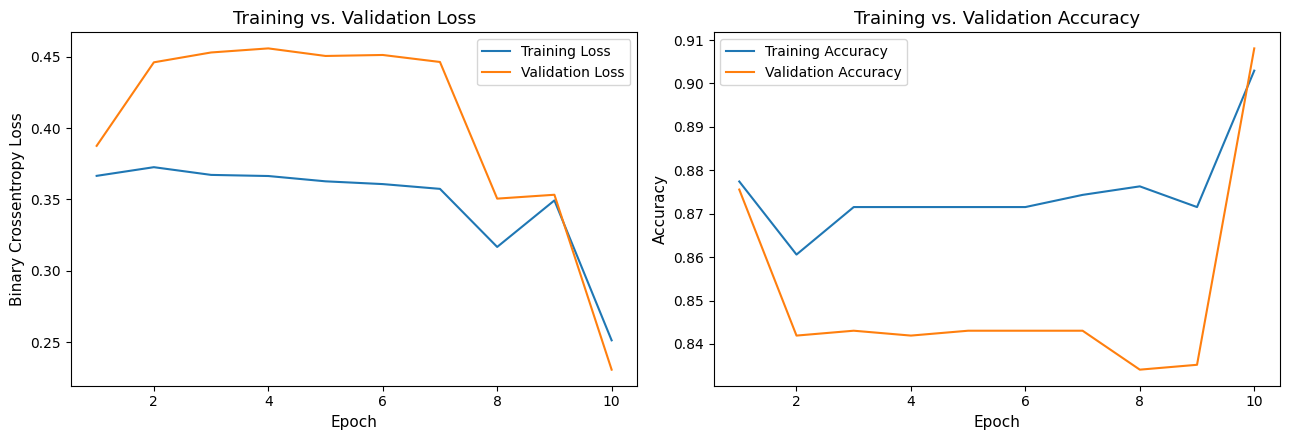

In [107]:
# Plotting

epochs_range = range(1, len(history.history["loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Loss Curve
ax1.plot(
    epochs_range,
    history.history["loss"],
    label="Training Loss",
)
ax1.plot(
    epochs_range,
    history.history["val_loss"],
    label="Validation Loss",
)
ax1.set_title("Training vs. Validation Loss", fontsize=13)
ax1.set_xlabel("Epoch", fontsize=11)
ax1.set_ylabel("Binary Crossentropy Loss", fontsize=11)
ax1.legend()

# Accuracy Curve
ax2.plot(
    epochs_range,
    history.history["accuracy"],
    label="Training Accuracy",
)
ax2.plot(
    epochs_range,
    history.history["val_accuracy"],
    label="Validation Accuracy",
)
ax2.set_title("Training vs. Validation Accuracy", fontsize=13)
ax2.set_xlabel("Epoch", fontsize=11)
ax2.set_ylabel("Accuracy", fontsize=11)
ax2.legend()

plt.tight_layout()
plt.show()

Vanishing Gradient Problem in Plain RNNs

During backpropagation through time (BPTT), gradients are repeatedly multiplied across sequence steps by the recurrent weight matrix and activation function derivatives (such as $\tanh$). When these factors are smaller than one, the propagated gradients decay exponentially toward zero, preventing the network from updating weights to learn dependencies between distant tokens.